## Preparing Dataset

In [1]:
import cv2
from IPython.display import display, Image

In [2]:
from roboflow import Roboflow

# Download dataset
from roboflow import Roboflow
rf = Roboflow(api_key="tlqtkBaMvXZHgwFP60pw")
project = rf.workspace("project-94aet").project("car-detection-vciny")
version = project.version(2)
dataset = version.download("yolov8")

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to car-detection-2 in yolov8:: 100%|██████████| 2008/2008 [00:00<00:00, 23319.69it/s]


## Train with Yolov8n Local

In [8]:
!yolo task=detect mode=train model=yolov8m.pt data="dataset/data.yaml" epochs=50 imgsz=640 plots=True

Ultralytics 8.3.239 🚀 Python-3.12.3 torch-2.9.1+cu128 CUDA:0 (NVIDIA GeForce RTX 5070, 11767MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=dataset/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8m.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=train2, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspective=0.0, plots=True, po

## Results

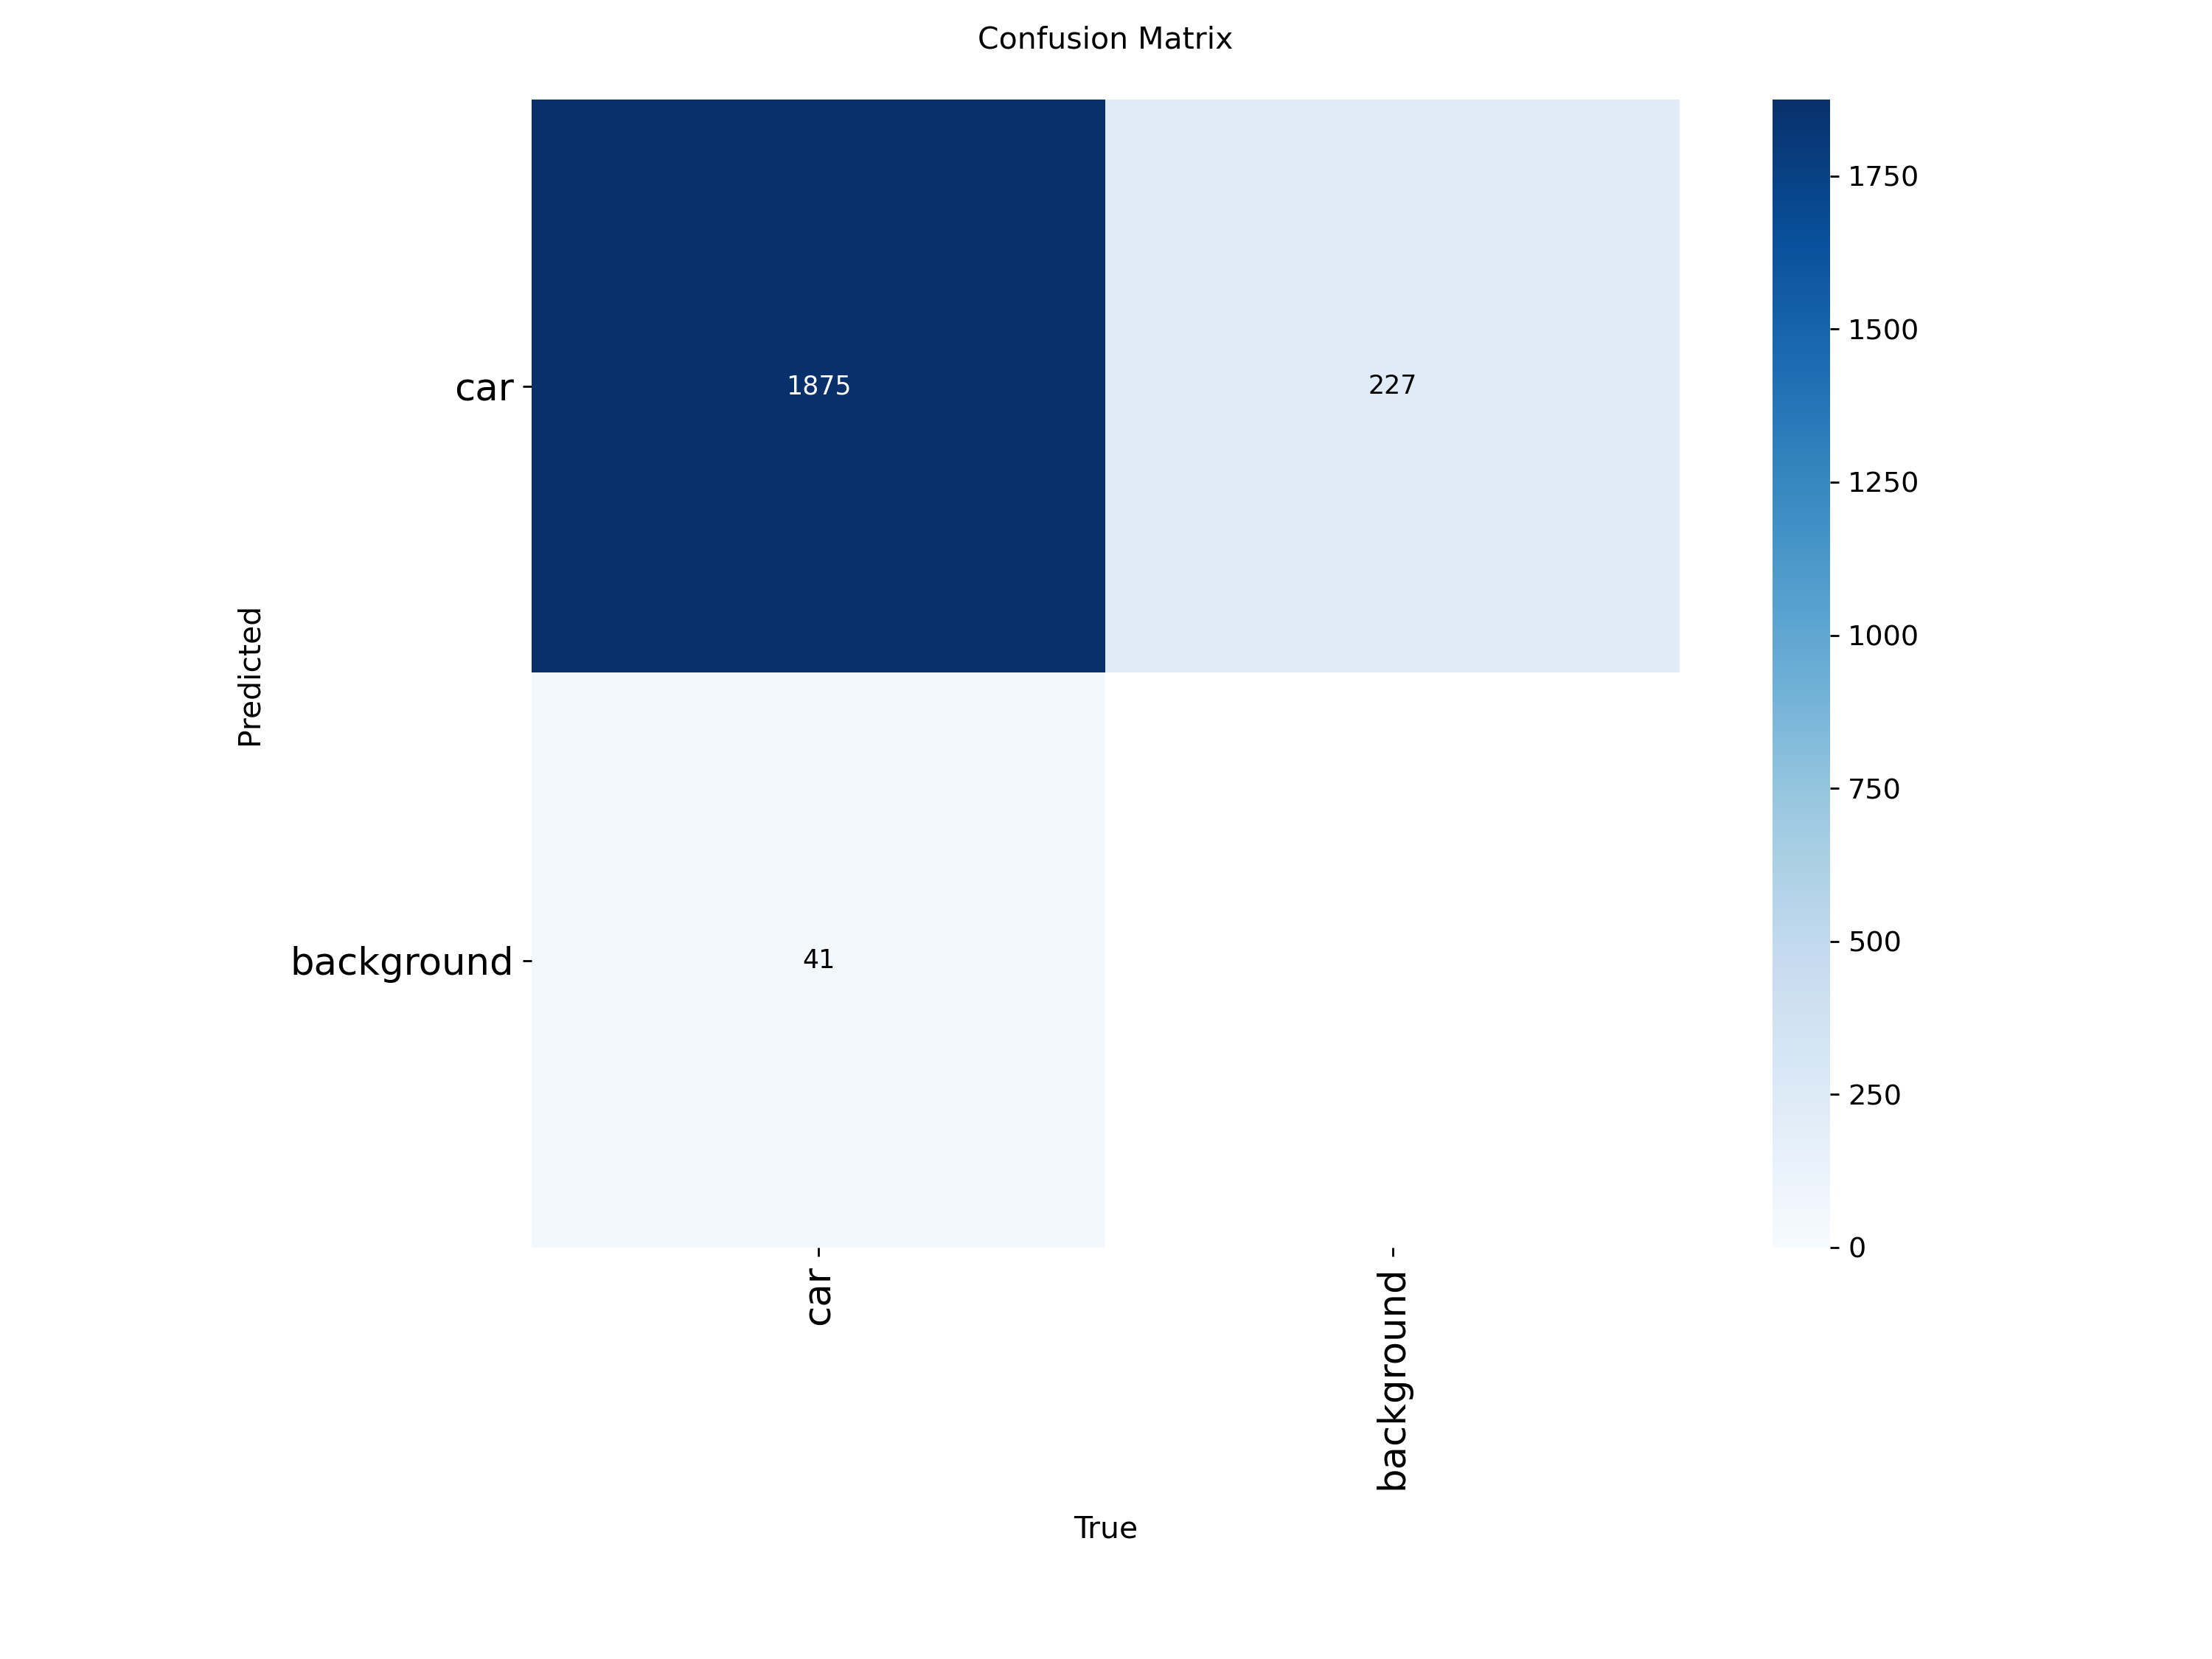

In [9]:
Image(filename='train/confusion_matrix.png', width=600)

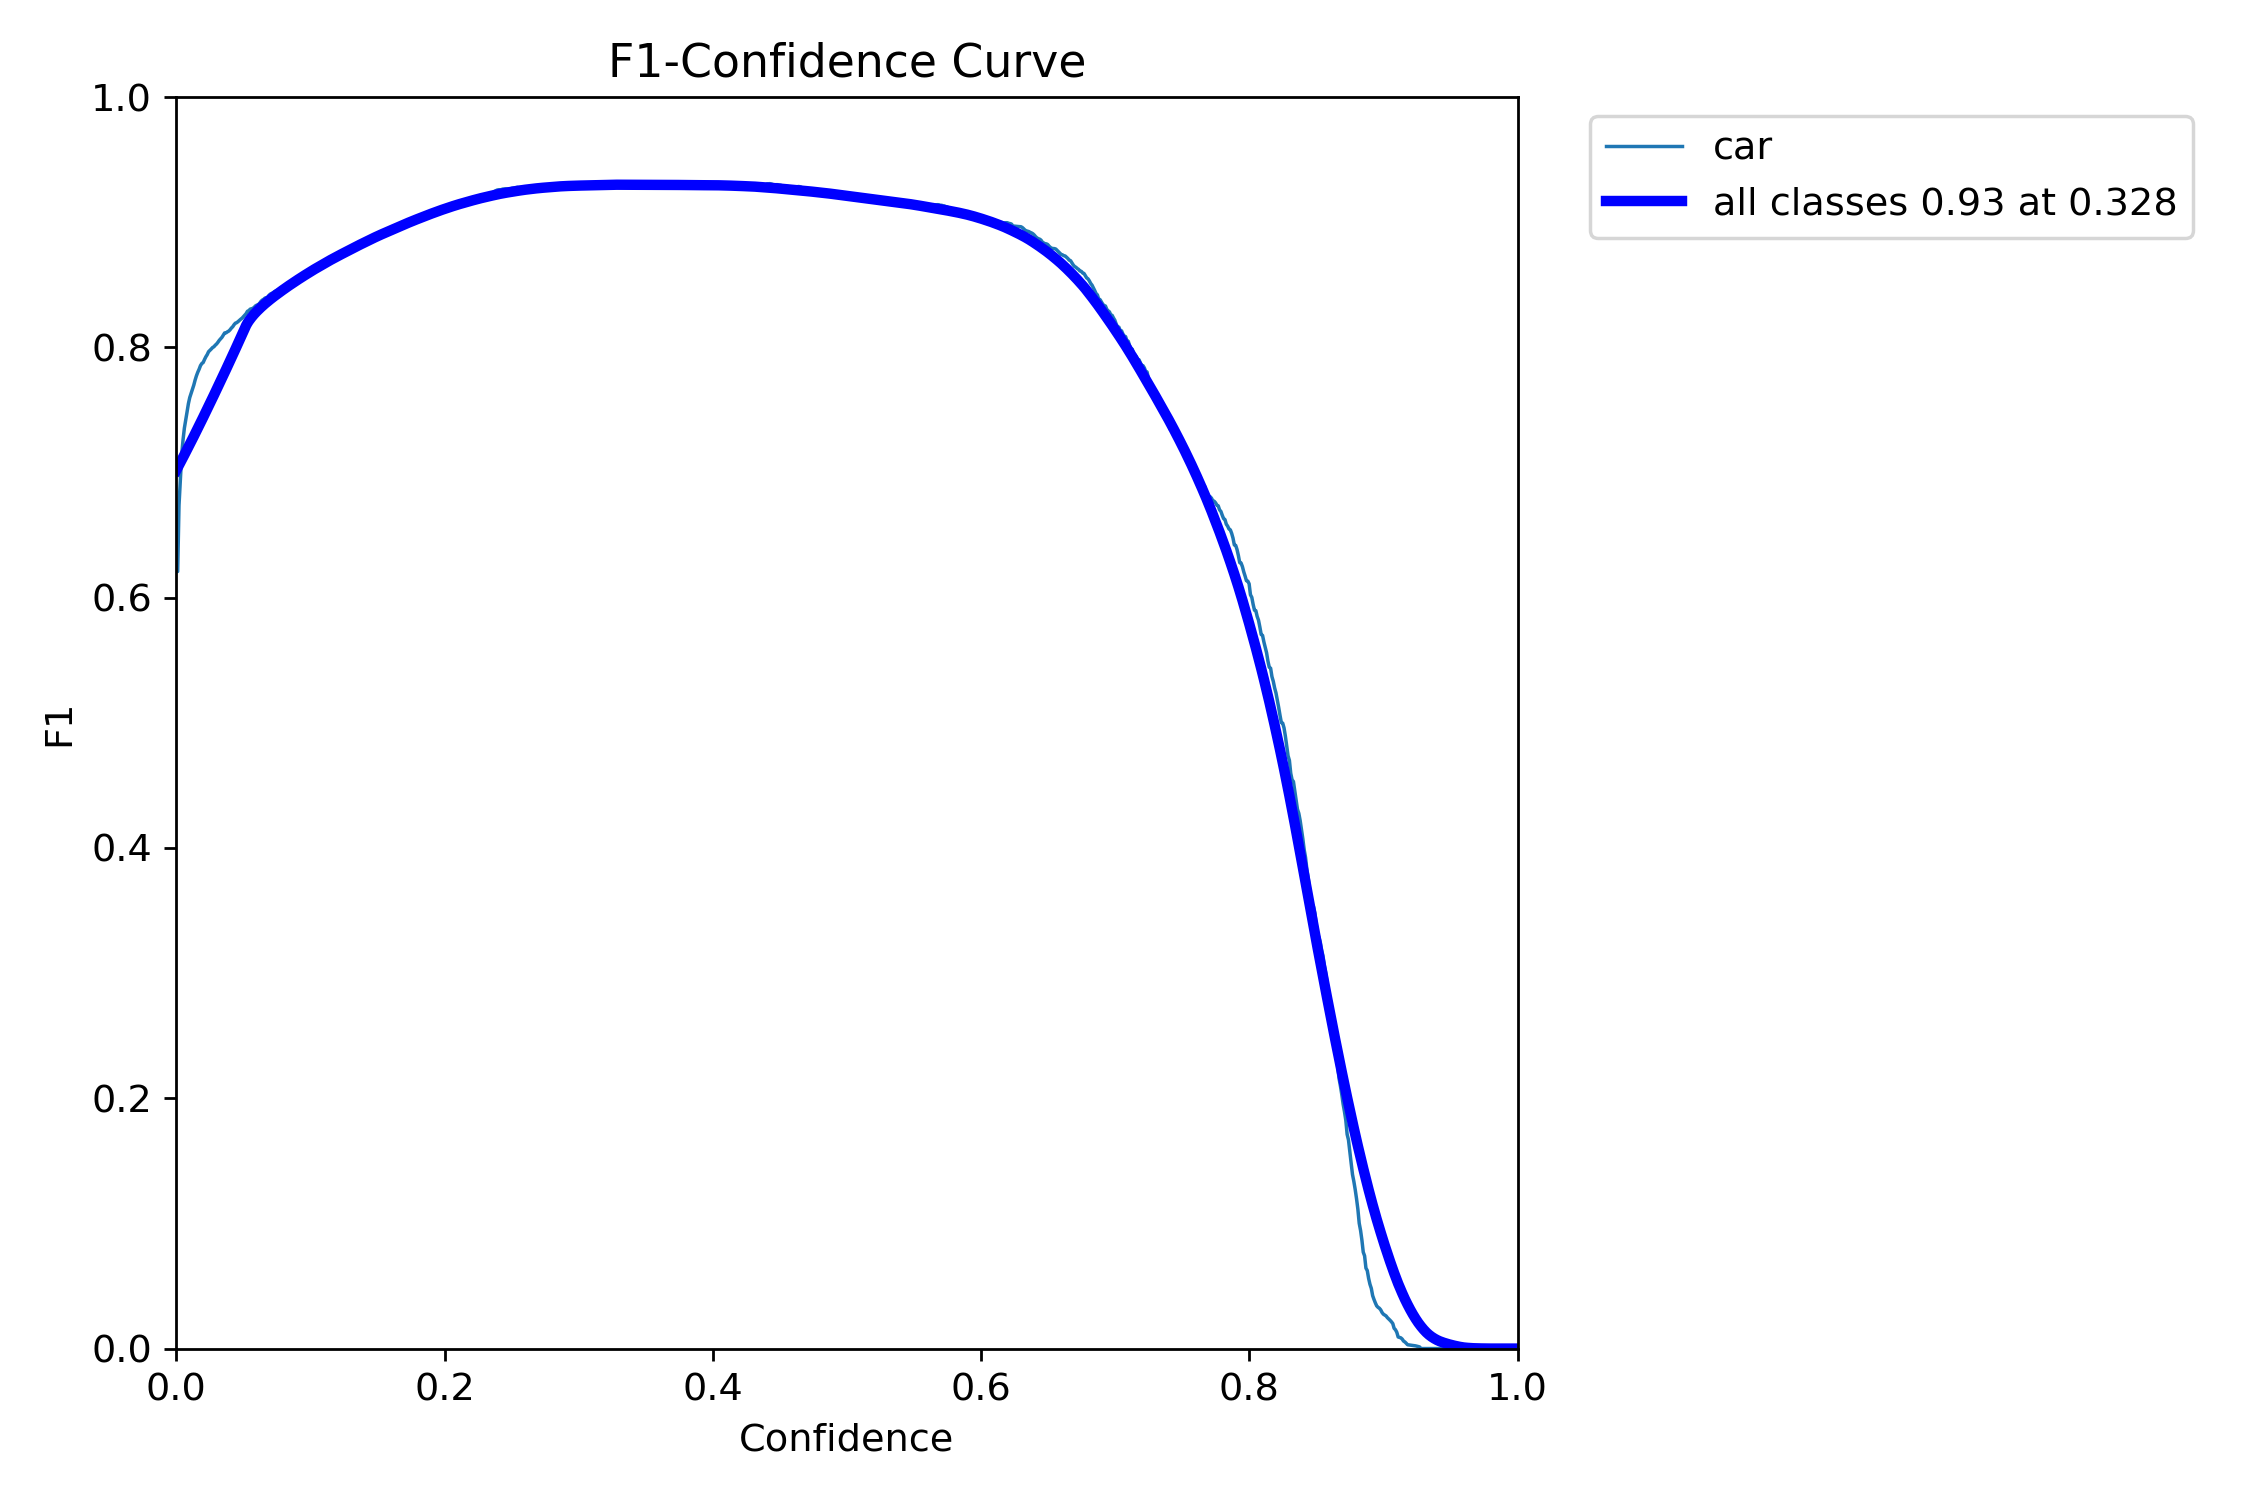

In [10]:
Image(filename='train/BoxF1_curve.png', width=600)

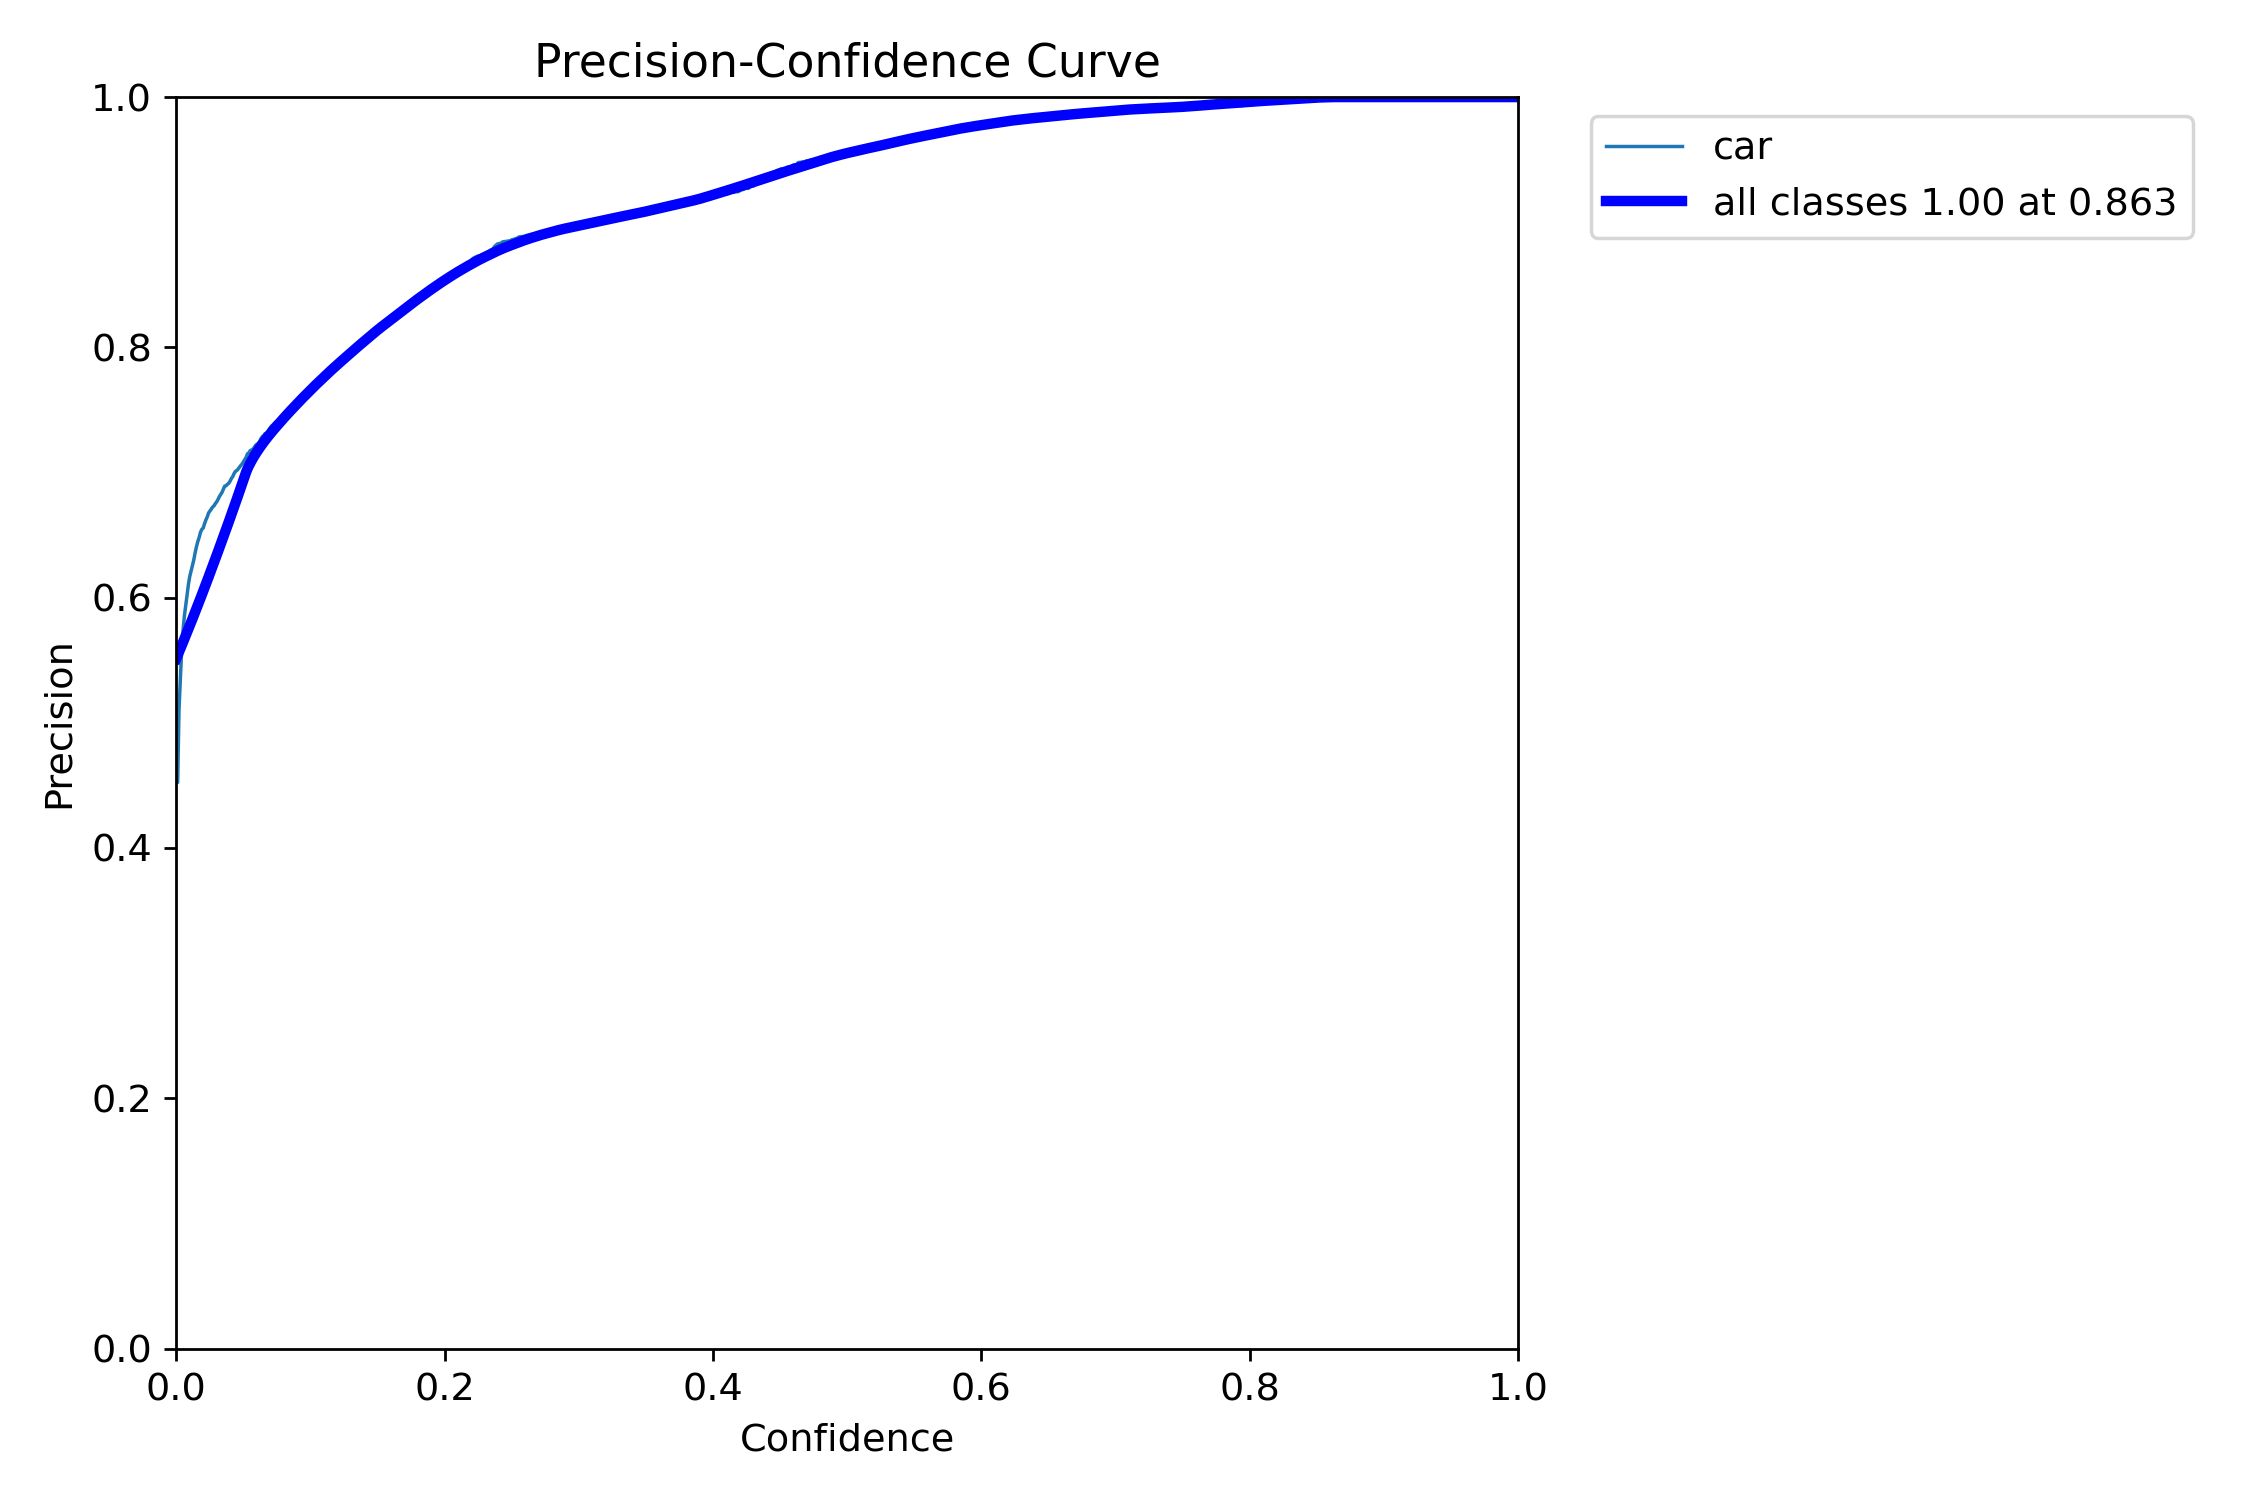

In [11]:
Image(filename='train/BoxP_curve.png', width=600)

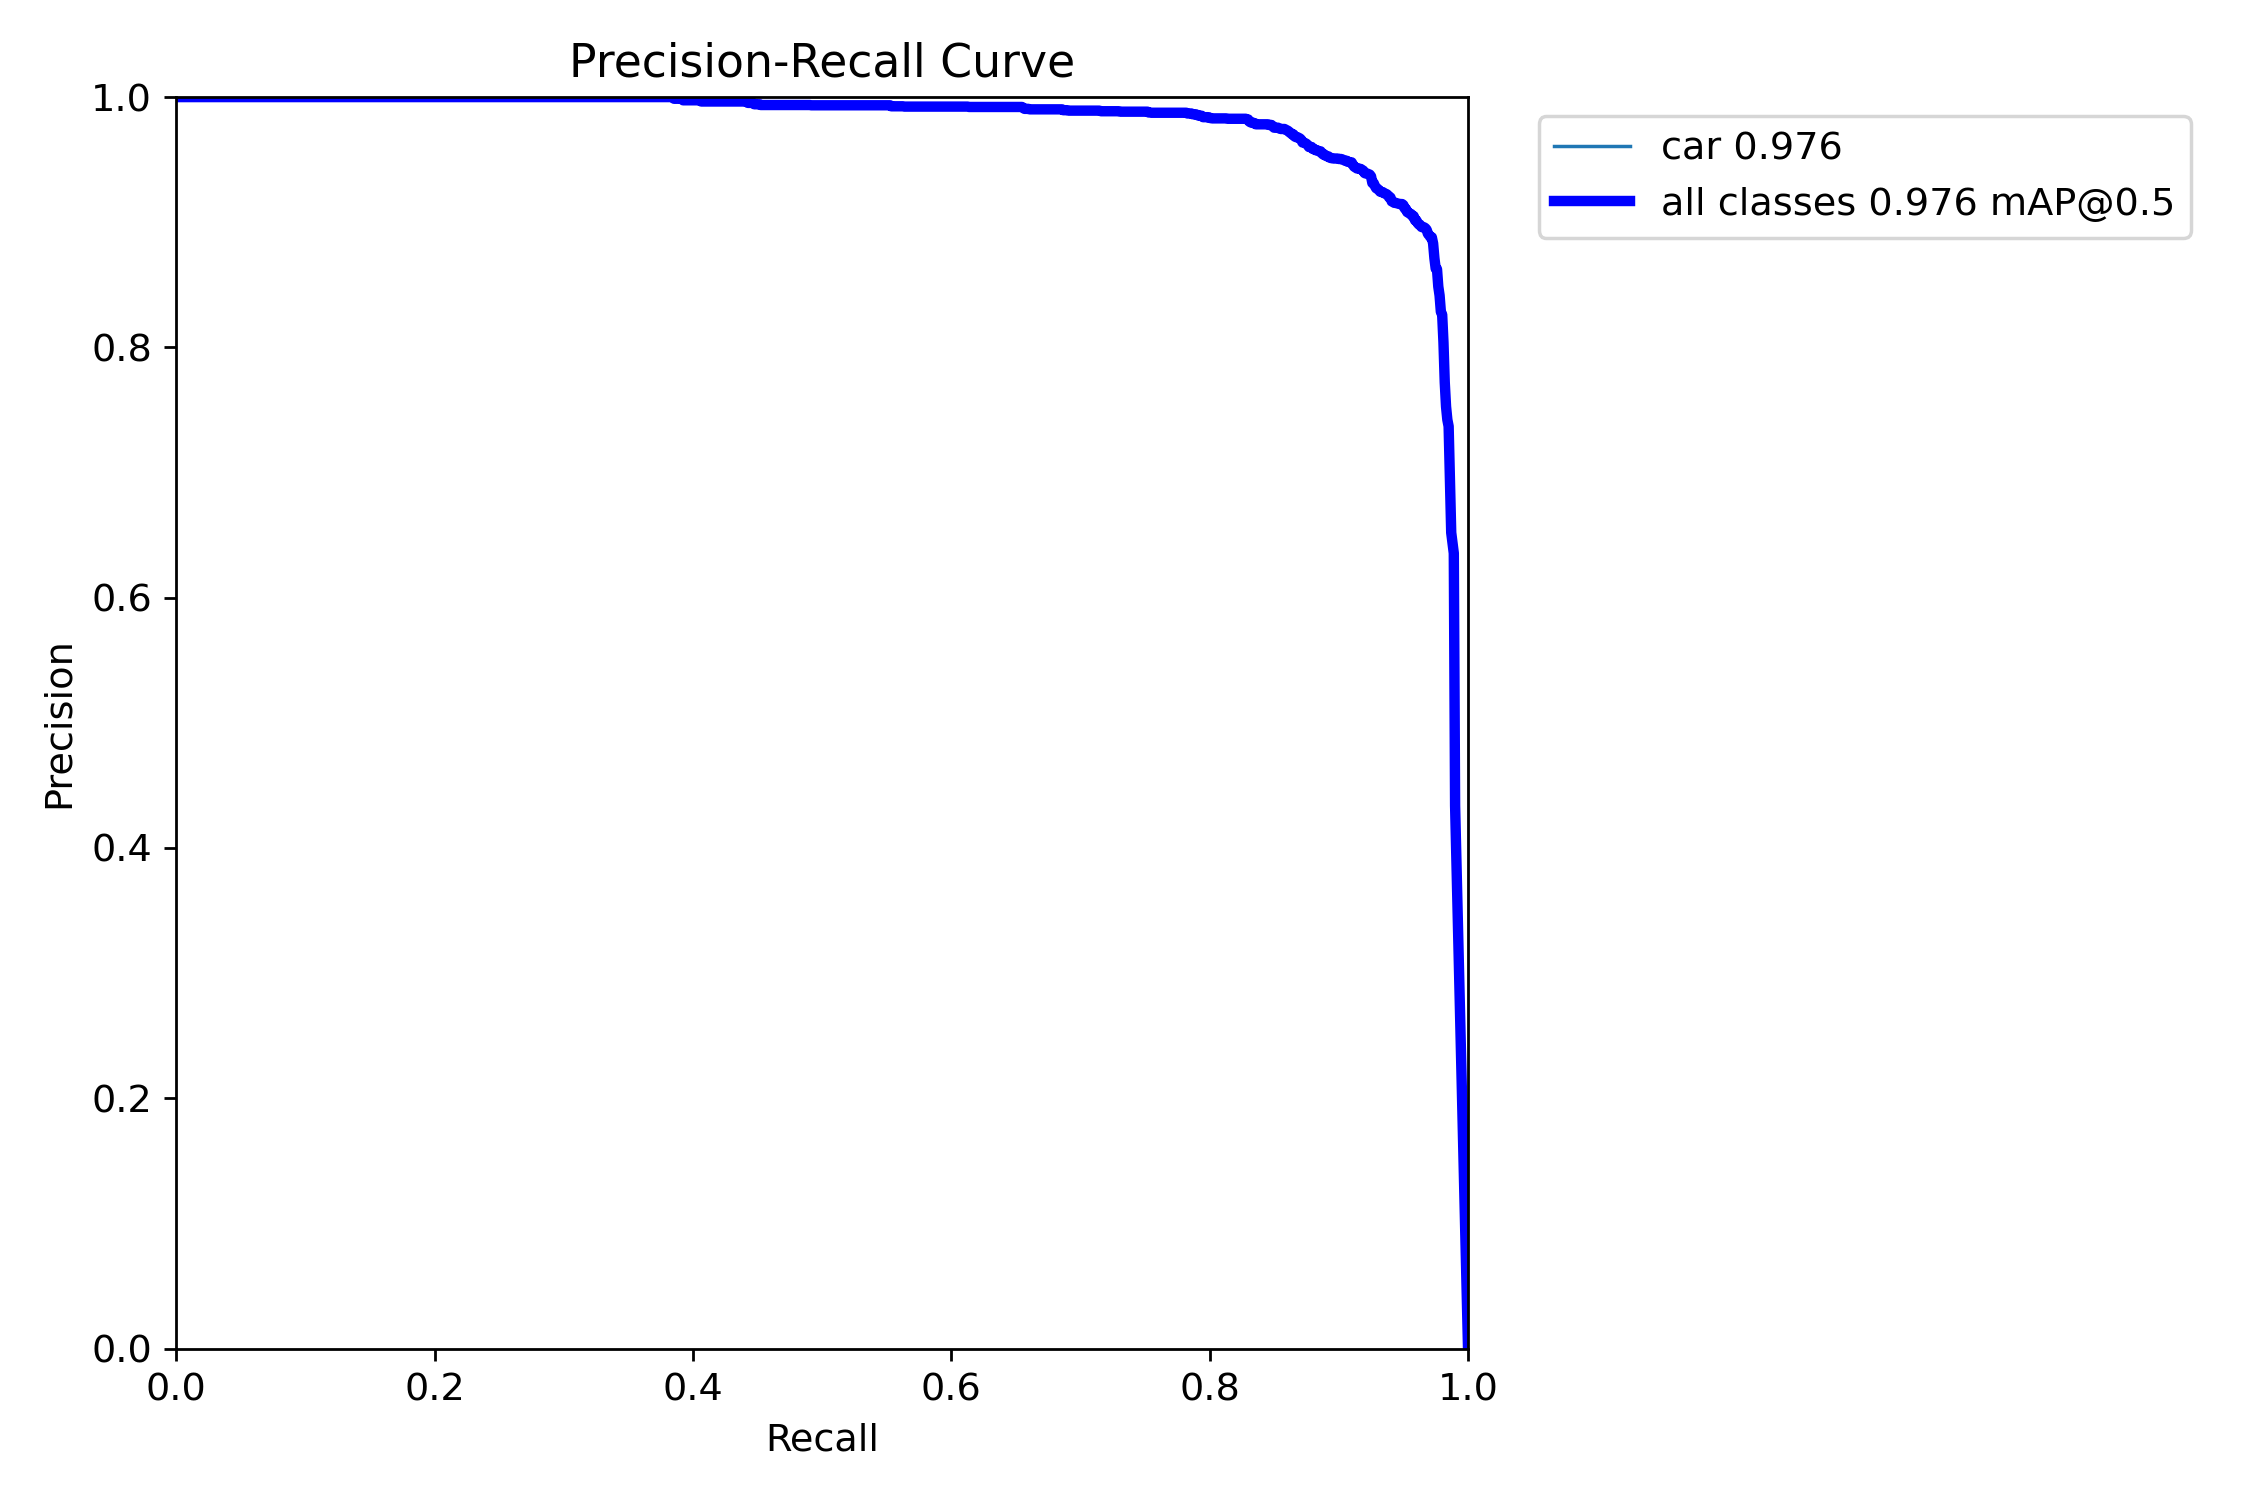

In [12]:
Image(filename='train/BoxPR_curve.png', width=600)

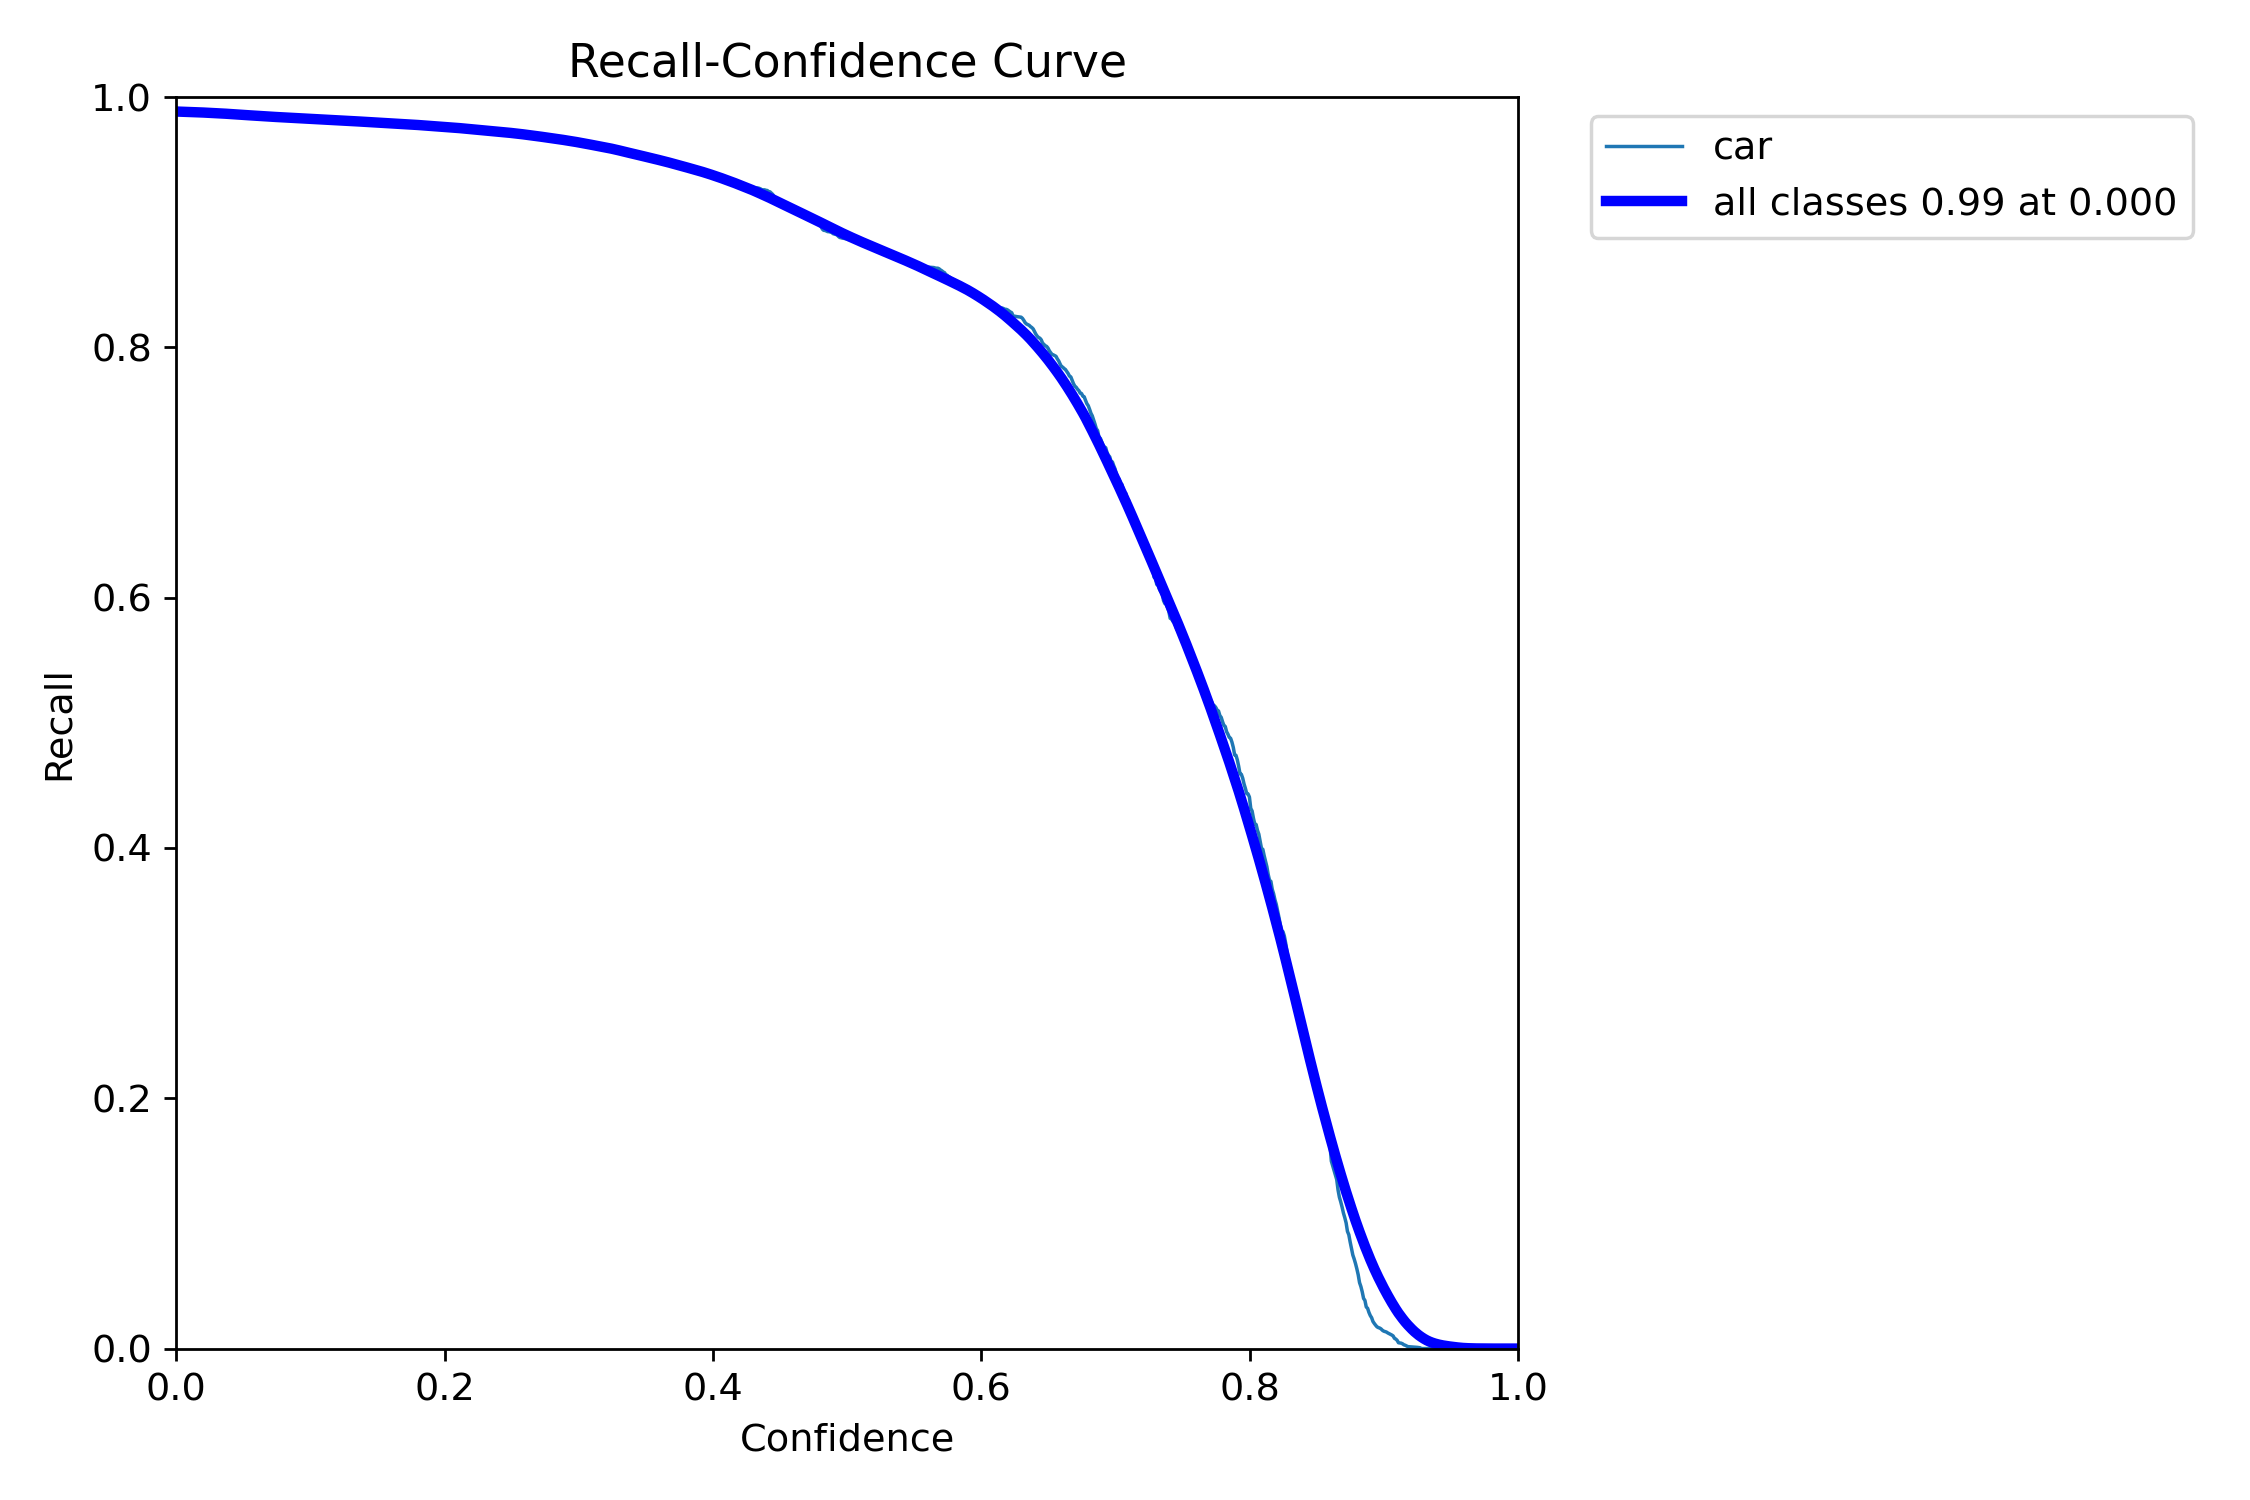

In [13]:
Image(filename='train/BoxR_curve.png', width=600)

## Validate

In [14]:
!yolo task=detect mode=val model="/home/ojan/parking-ilegal-model/train/weights/best.pt" data="dataset/data.yaml"

Ultralytics 8.3.239 🚀 Python-3.12.3 torch-2.9.1+cu128 CUDA:0 (NVIDIA GeForce RTX 5070, 11767MiB)
Model summary (fused): 92 layers, 25,840,339 parameters, 0 gradients, 78.7 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 6589.9±1159.2 MB/s, size: 77.6 KB)
val: Scanning /home/ojan/parking-ilegal-model/dataset/valid/labels.cache... 200 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 200/200 9.9Mit/s 0.0ss
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 13/13 7.7it/s 1.7s0.1s
                   all        200       1916      0.902      0.959      0.976      0.663
Speed: 0.7ms preprocess, 6.2ms inference, 0.0ms loss, 0.2ms postprocess per image
Results saved to /mnt/secondary/tools/lpr-nba-tools/runs/detect/val
💡 Learn more at https://docs.ultralytics.com/modes/val


## Predict

In [15]:
!yolo task=detect mode=predict model="/home/ojan/parking-ilegal-model/train/weights/best.pt" conf=0.25 source="/home/ojan/parking-ilegal-model/dataset/test/images" save=True

Ultralytics 8.3.239 🚀 Python-3.12.3 torch-2.9.1+cu128 CUDA:0 (NVIDIA GeForce RTX 5070, 11767MiB)
Model summary (fused): 92 layers, 25,840,339 parameters, 0 gradients, 78.7 GFLOPs

image 1/100 /home/ojan/parking-ilegal-model/dataset/test/images/frame_0000_jpg.rf.41c4c40843cff9ec0d0c3806ad6640ed.jpg: 640x640 9 cars, 6.4ms
image 2/100 /home/ojan/parking-ilegal-model/dataset/test/images/frame_0008_jpg.rf.3b4dac1a5e9120aa30c41e24b0d33b24.jpg: 640x640 8 cars, 6.4ms
image 3/100 /home/ojan/parking-ilegal-model/dataset/test/images/frame_0008_jpg.rf.ec2a9d0fc3124ed8610607bcc1259c1d.jpg: 640x640 8 cars, 6.3ms
image 4/100 /home/ojan/parking-ilegal-model/dataset/test/images/frame_0011_jpg.rf.2b403f4e1ba865ba121fbb6b8aecc243.jpg: 640x640 8 cars, 6.4ms
image 5/100 /home/ojan/parking-ilegal-model/dataset/test/images/frame_0012_jpg.rf.421d168d77de6a649f9f627eec16cb98.jpg: 640x640 8 cars, 6.3ms
image 6/100 /home/ojan/parking-ilegal-model/dataset/test/images/frame_0018_jpg.rf.da50de21ad472458702a784f883d

## Result Predict

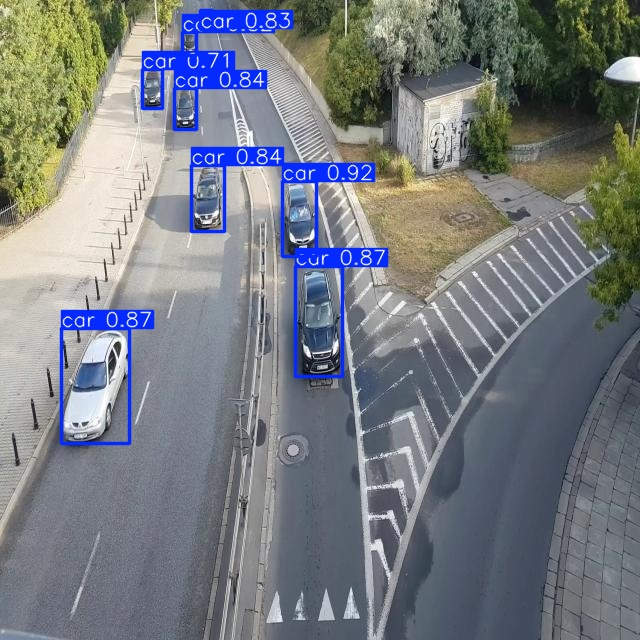

In [17]:
Image(filename='/home/ojan/parking-ilegal-model/predict/frame_0012_jpg.rf.421d168d77de6a649f9f627eec16cb98.jpg', width=600)

In [19]:
!yolo task=detect mode=predict model="/home/ojan/parking-ilegal-model/train/weights/best.pt" conf=0.5 source="/home/ojan/parking-ilegal-model/test-sample/test.mp4" save=True

Ultralytics 8.3.239 🚀 Python-3.12.3 torch-2.9.1+cu128 CUDA:0 (NVIDIA GeForce RTX 5070, 11767MiB)
Model summary (fused): 92 layers, 25,840,339 parameters, 0 gradients, 78.7 GFLOPs

video 1/1 (frame 1/767) /home/ojan/parking-ilegal-model/test-sample/test.mp4: 384x640 (no detections), 21.9ms
video 1/1 (frame 2/767) /home/ojan/parking-ilegal-model/test-sample/test.mp4: 384x640 (no detections), 5.1ms
video 1/1 (frame 3/767) /home/ojan/parking-ilegal-model/test-sample/test.mp4: 384x640 (no detections), 7.5ms
video 1/1 (frame 4/767) /home/ojan/parking-ilegal-model/test-sample/test.mp4: 384x640 (no detections), 5.1ms
video 1/1 (frame 5/767) /home/ojan/parking-ilegal-model/test-sample/test.mp4: 384x640 (no detections), 5.1ms
video 1/1 (frame 6/767) /home/ojan/parking-ilegal-model/test-sample/test.mp4: 384x640 (no detections), 5.1ms
video 1/1 (frame 7/767) /home/ojan/parking-ilegal-model/test-sample/test.mp4: 384x640 (no detections), 7.5ms
video 1/1 (frame 8/767) /home/ojan/parking-ilegal-model/